# [4] Band Stacking + Clipping

> Making use of H3 global grid indexing when working with rasters. For this example series, we focus on B04 (red), B03 (green), B02 (blue), and B08 (nir).

---
__Last Update:__ June 19, 2026

This notebook uses the **lightweight RasterX tier** ([Execution Tiers](https://databrickslabs.github.io/geobrix/docs/api/execution-tiers), [RasterX Functions](https://databrickslabs.github.io/geobrix/docs/api/raster-functions)) to stack multiple single-band rasters into multi-band tiles and clip them to vector boundaries. Key functions: `rst_frombands` (assemble bands into a multi-band tile), `rst_clip` (vector-aligned clipping with automatic CRS handling), and `rst_merge_agg` (aggregate per-cell grids across overlapping scenes).

## Imports + Config

In [0]:
import warnings
warnings.filterwarnings(
    "ignore",
    message=r".*make_tokens_by_line.*received a list of lines.*",
    category=UserWarning,
)

In [0]:
%run ./config_nb

__Libraries__

* GeoBrix assumed already installed on the cluster.
* Python bindings now are `databricks.labs.gbx.rasterx` (etc).
* Pandas now at 2.2.3 with DBR17.3
* Match GDAL to version installed with natives (3.11.4).

__Unity Catalog__

* Replace `catalog_name` and `schema_name` with your preferred locations.
* Volume 'data' must exist under `catalog_name`/`schema_name`.

Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.


... catalog: 'geospatial_docs' (USE)
... schema: 'eo_series' (CREATE / USE)


... ETL_DIR: '/Volumes/geospatial_docs/eo_series/data'
... EO_DIR: '/Volumes/geospatial_docs/eo_series/data/alaska' (MKDIRS)


## Data load

> _We are focusing on the gridded tables for band stacking and NDVI._

__Note:__ Since NDVI is pixel-by-pixel, the hex clipping is not of concern. For other operations, we might do more square re-tiling.

In [0]:
%sql show tables

database,tableName,isTemporary
eo_series_fresh,band_b02,false
eo_series_fresh,band_b02_h3,false
eo_series_fresh,band_b02_tile,false
eo_series_fresh,band_b03,false
eo_series_fresh,band_b03_h3,false
eo_series_fresh,band_b03_tile,false
eo_series_fresh,band_b04,false
eo_series_fresh,band_b04_h3,false
eo_series_fresh,band_b04_tile,false
eo_series_fresh,band_b08,false


In [0]:
df_b02_h3 = spark.read.table("band_b02_h3")
df_b03_h3 = spark.read.table("band_b03_h3")
df_b04_h3 = spark.read.table("band_b04_h3")
df_b08_h3 = spark.read.table("band_b08_h3")

## Band Stacking

> We are going to merge bands into rasters from the same h3 cells.

_[1] Consolidate to 1 tile per H3 cell per day with `rst_merge_agg` aggregate function._ __Note: the following shows the multiple tiles in some cells.__

In [0]:
display(
  df_b02_h3.groupBy("cellid", "date", "band_name")
    .count()
  .orderBy(F.desc("count"))
  .limit(25)
)

cellid,date,band_name,count
608314964842643455,2022-06-01,B02,8
608314919275724799,2022-06-01,B02,8
608314920064253951,2022-06-01,B02,7
608314920097808383,2022-06-01,B02,7
608314920047476735,2022-06-01,B02,7
608314920399798271,2022-06-01,B02,7
608314920265580543,2022-06-01,B02,7
608314920081031167,2022-06-01,B02,7
608314920248803327,2022-06-01,B02,7
608314963936673791,2022-06-01,B02,6


`rst_merge_agg` is a grouped aggregate that merges multiple overlapping tiles for the same H3 cell into a single tile. This resolves cases where a raster scene covers a cell boundary and produces two partial tiles for the same cell-date combination.

In [0]:
df_b02_resolved = df_b02_h3.groupBy("cellid", "date", "band_name")\
  .agg(rx.rst_merge_agg("tile").alias("tile"))

df_b03_resolved = df_b03_h3.groupBy("cellid", "date", "band_name")\
  .agg(rx.rst_merge_agg("tile").alias("tile"))

df_b04_resolved = df_b04_h3.groupBy("cellid", "date", "band_name")\
  .agg(rx.rst_merge_agg("tile").alias("tile"))

df_b08_resolved = df_b08_h3.groupBy("cellid", "date", "band_name")\
  .agg(rx.rst_merge_agg("tile").alias("tile"))

_Here is example of the resolved output._

In [0]:
print(f"band 02 resolved count? {df_b02_resolved.count():,}")
df_b02_resolved.limit(10).display()

band 02 resolved count? 21,268


cellid,date,band_name,tile
608315070203559935,2022-06-01,B02,"List(608315070203559935, SUkqAAgAAAASAAABAwABAAAA6AAAAAEBAwABAAAABAEAAAIBAwABAAAAEAAAAAMBAwABAAAACAAAAAYBAwABAAAAAQAAABUBAwABAAAAAQAAABwBAwABAAAAAQAAAD0BAwABAAAAAgAAAEIBAwABAAAA4AAAAEMBAwABAAAA4AA= (truncated), Map(format -> GTiff, path -> /vsimem/merge_rasters_36684d78_4934_4c4d_887c_524a85f8c8b1.tif, size -> -1, compression -> DEFLATE, last_error -> , all_parents -> /vsimem/merge_rasters_36684d78_4934_4c4d_887c_524a85f8c8b1.vrt;/vsimem/temp_raster_6a4ccf28_051e_402d_90f3_b4ee8e8af1b3.tif;/vsimem/temp_raster_fe5900dc_0957_4f73_8ff5_32b90ca6ef69.tif, isZipped -> false, driver -> GTiff, sourcePath -> /vsimem/merge_rasters_36684d78_4934_4c4d_887c_524a85f8c8b1.vrt, last_command -> gdal_translate -of GTiff -co TILED=YES -co BLOCKXSIZE=224 -co BLOCKYSIZE=224 -co BIGTIFF=IF_SAFER -co COMPRESS=DEFLATE -co PREDICTOR=2 -co ZLEVEL=6, isSubset -> false))"
608315074901180415,2022-06-01,B02,"List(608315074901180415, SUkqAAgAAAATAAABAwABAAAA6gAAAAEBAwABAAAABAEAAAIBAwABAAAAEAAAAAMBAwABAAAACAAAAAYBAwABAAAAAQAAABUBAwABAAAAAQAAABwBAwABAAAAAQAAAD0BAwABAAAAAgAAAEIBAwABAAAA4AAAAEMBAwABAAAA4AA= (truncated), Map(format -> GTiff, path -> /vsimem/clip_to_geom_2e21c711_823a_426d_bcd7_24c16c0c9453.tif, size -> -1, compression -> DEFLATE, last_error -> , all_parents -> /vsimem/temp_raster_f587fd98_2093_42cd_ad20_1ad1db3f6ccd.tif, isZipped -> false, driver -> GTiff, parentPath -> /vsimem/initnodata_be0c9408-e3a6-4427-b6bc-cd940bc9554d.tif, last_command -> gdalwarp -q -wo CUTLINE_ALL_TOUCHED=TRUE -cutline /tmp/gdal_local_files/3bc2e94a/7c00772b_eade_4b36_9fe4_23f001ea66f0/clip_7c00772b_eade_4b36_9fe4_23f001ea66f0.csv -crop_to_cutline -oo GEOM_POSSIBLE_NAMES=WKT -of GTiff -co TILED=YES -co BLOCKXSIZE=512 -co BLOCKYSIZE=512 -co BIGTIFF=IF_SAFER -co COMPRESS=DEFLATE -co PREDICTOR=2 -co ZLEVEL=6, isSubset -> false))"
608315080336998399,2022-06-01,B02,"List(608315080336998399, SUkqAAgAAAASAAABAwABAAAA6AAAAAEBAwABAAAAAwEAAAIBAwABAAAAEAAAAAMBAwABAAAACAAAAAYBAwABAAAAAQAAABUBAwABAAAAAQAAABwBAwABAAAAAQAAAD0BAwABAAAAAgAAAEIBAwABAAAA4AAAAEMBAwABAAAA4AA= (truncated), Map(format -> GTiff, path -> /vsimem/merge_rasters_a1c862a1_b4e0_4977_841f_9daa8551ebb9.tif, size -> -1, compression -> DEFLATE, last_error -> , all_parents -> /vsimem/merge_rasters_a1c862a1_b4e0_4977_841f_9daa8551ebb9.vrt;/vsimem/temp_raster_b81e82b0_add8_47f3_911c_6c4176455521.tif;/vsimem/temp_raster_e0063d45_51fa_4988_a88d_a3011f3eb3a4.tif, isZipped -> false, driver -> GTiff, sourcePath -> /vsimem/merge_rasters_a1c862a1_b4e0_4977_841f_9daa8551ebb9.vrt, last_command -> gdal_translate -of GTiff -co TILED=YES -co BLOCKXSIZE=224 -co BLOCKYSIZE=224 -co BIGTIFF=IF_SAFER -co COMPRESS=DEFLATE -co PREDICTOR=2 -co ZLEVEL=6, isSubset -> false))"
608315084950732799,2022-06-01,B02,"List(608315084950732799, SUkqAAgAAAASAAABAwABAAAA6QAAAAEBAwABAAAABQEAAAIBAwABAAAAEAAAAAMBAwABAAAACAAAAAYBAwABAAAAAQAAABUBAwABAAAAAQAAABwBAwABAAAAAQAAAD0BAwABAAAAAgAAAEIBAwABAAAA4AAAAEMBAwABAAAA4AA= (truncated), Map(format -> GTiff, path -> /vsimem/merge_rasters_d81c07b2_8f64_4c35_8ff1_89dfa2473cf8.tif, size -> -1, compression -> DEFLATE, last_error -> , all_parents -> /vsimem/merge_rasters_d81c07b2_8f64_4c35_8ff1_89dfa2473cf8.vrt;/vsimem/temp_raster_c18d8bb8_ab29_4438_ae62_a347085a9be0.tif;/vsimem/temp_raster_feaf6106_37c9_4d06_b50e_2764e31248f6.tif, isZipped -> false, driver -> GTiff, sourcePath -> /vsimem/merge_rasters_d81c07b2_8f64_4c35_8ff1_89dfa2473cf8.vrt, last_command -> gdal_translate -of GTiff -co TILED=YES -co BLOCKXSIZE=224 -co BLOCKYSIZE=224 -co BIGTIFF=IF_SAFER -co COMPRESS=DEFLATE -co PREDICTOR=2 -co ZLEVEL=6, isSubset -> false))"
608311857031151615,2022-06-01,B02,"List(608311857031151615, SUkqAAgAAAATAAABAwABAAAA6gAAAAEBAwABAAAAAgEAAAIBAwABAAAAEAAAAAMBAwABAAAACAAAAAYBAwABAAAAAQAAABUBAwABAAAAAQAAABwBAwABAAAAAQAAAD0BAwABAAAAAgAAAEIBAwABAAAA4AAAAEMBAwABAAAA4AA= (truncated), Map(format -> GTiff, path -> /vsimem/clip_to_geom_c2cd25ae_ec0b_4fef_b96b_93790385f892.tif, s

_[2] Band stack per H3 tile; in this case, red, green, blue, and nir (4 bands)._

_[a] Here is a brief example of using union and window to stack by (ordered) band_name, using one of the cellids from above._

Inspect the per-band tile structure before stacking: `rst_numbands` returns the band count, `rst_width`/`rst_height` return pixel dimensions, and `rst_memsize` returns the in-memory footprint in bytes. `rst_initnodata` masks no-data pixels so they are excluded from downstream band math.

In [0]:
stack_win = Window.partitionBy("cellid","date").orderBy('band_name')
cellid_stack = 608314919275724799

display (
  df_b02_resolved
    .withColumn("tile", rx.rst_initnodata("tile"))
    .filter(f"cellid = {cellid_stack}")
  .union(
    df_b03_resolved
      .withColumn("tile", rx.rst_initnodata("tile"))
      .filter(f"cellid = {cellid_stack}")
  )
  .union(
    df_b04_resolved
      .withColumn("tile", rx.rst_initnodata("tile"))
      .filter(f"cellid = {cellid_stack}")
  )
  .union(
    df_b08_resolved
      .withColumn("tile", rx.rst_initnodata("tile"))
      .filter(f"cellid = {cellid_stack}")
  )
  .select(
    "date",
    F
      .collect_list("tile")
        .over(stack_win)
      .alias("tiles")
  )
  .filter("array_size(tiles) = 4")
  .withColumn("tile", rx.rst_frombands("tiles"))
  .withColumn("memsize", rx.rst_memsize("tile"))
  .withColumn("num_bands", rx.rst_numbands("tile"))
)

date,tiles,tile,memsize,num_bands
2022-06-01,"List(List(608314919275724799, SUkqAAgAAAASAAABAwABAAAA5wAAAAEBAwABAAAA/wAAAAIBAwABAAAAEAAAAAMBAwABAAAACAAAAAYBAwABAAAAAQAAABUBAwABAAAAAQAAABwBAwABAAAAAQAAAD0BAwABAAAAAgAAAEIBAwABAAAA4AAAAEMBAwABAAAA4AA= (truncated), Map(format -> GTiff, path -> /vsimem/initnodata_bc8bc463-837f-4d8b-b0e3-87405a09a620.tif, size -> -1, compression -> DEFLATE, last_error -> , all_parents -> /vsimem/temp_raster_5d958150_0a91_40c6_8c60_5861ec5ed8fd.tif, isZipped -> false, driver -> GTiff, parentPath -> /vsimem/merge_rasters_937f23f4_578b_42d2_8efd_83358187ada4.tif, last_command -> gdalwarp -dstnodata ""65535.0"" -of GTiff -co TILED=YES -co BLOCKXSIZE=224 -co BLOCKYSIZE=224 -co BIGTIFF=IF_SAFER -co COMPRESS=DEFLATE -co PREDICTOR=2 -co ZLEVEL=6, isSubset -> false)), List(608314919275724799, SUkqAAgAAAASAAABAwABAAAA5wAAAAEBAwABAAAA/wAAAAIBAwABAAAAEAAAAAMBAwABAAAACAAAAAYBAwABAAAAAQAAABUBAwABAAAAAQAAABwBAwABAAAAAQAAAD0BAwABAAAAAgAAAEIBAwABAAAA4AAAAEMBAwABAAAA4AA= (truncated), Map(format -> GTiff, path -> /vsimem/initnodata_8df4b8f0-30cf-4647-b0f1-3ed9166cfc66.tif, size -> -1, compression -> DEFLATE, last_error -> , all_parents -> /vsimem/temp_raster_884c9f6a_35fd_4287_b8cb_92cf1b54cde4.tif, isZipped -> false, driver -> GTiff, parentPath -> /vsimem/merge_rasters_97131ede_d585_4aef_a926_394bc79f5efb.tif, last_command -> gdalwarp -dstnodata ""65535.0"" -of GTiff -co TILED=YES -co BLOCKXSIZE=224 -co BLOCKYSIZE=224 -co BIGTIFF=IF_SAFER -co COMPRESS=DEFLATE -co PREDICTOR=2 -co ZLEVEL=6, isSubset -> false)), List(608314919275724799, SUkqAAgAAAASAAABAwABAAAA5wAAAAEBAwABAAAA/wAAAAIBAwABAAAAEAAAAAMBAwABAAAACAAAAAYBAwABAAAAAQAAABUBAwABAAAAAQAAABwBAwABAAAAAQAAAD0BAwABAAAAAgAAAEIBAwABAAAA4AAAAEMBAwABAAAA4AA= (truncated), Map(format -> GTiff, path -> /vsimem/initnodata_7f7c56b9-78db-4237-85f4-9017909e3435.tif, size -> -1, compression -> DEFLATE, last_error -> , all_parents -> /vsimem/temp_raster_fb1c7aaa_d820_4b3b_a262_9a704a0b133e.tif, isZipped -> false, driver -> GTiff, parentPath -> /vsimem/merge_rasters_eb28e0ad_6b73_497f_8634_5d6da5178691.tif, last_command -> gdalwarp -dstnodata ""65535.0"" -of GTiff -co TILED=YES -co BLOCKXSIZE=224 -co BLOCKYSIZE=224 -co BIGTIFF=IF_SAFER -co COMPRESS=DEFLATE -co PREDICTOR=2 -co ZLEVEL=6, isSubset -> false)), List(608314919275724799, SUkqAAgAAAASAAABAwABAAAA5wAAAAEBAwABAAAA/wAAAAIBAwABAAAAEAAAAAMBAwABAAAACAAAAAYBAwABAAAAAQAAABUBAwABAAAAAQAAABwBAwABAAAAAQAAAD0BAwABAAAAAgAAAEIBAwABAAAA4AAAAEMBAwABAAAA4AA= (truncated), Map(format -> GTiff, path -> /vsimem/initnodata_42beb7a6-3953-4a16-8ac1-8744228e62a4.tif, size -> -1, compression -> DEFLATE, last_error -> , all_parents -> /vsimem/temp_raster_18309b65_2076_4444_843a_eaf88074485f.tif, isZipped -> false, driver -> GTiff, parentPath -> /vsimem/merge_rasters_ca146821_541a_4948_8c17_455183a378c1.tif, last_command -> gdalwarp -dstnodata ""65535.0"" -of GTiff -co TILED=YES -co BLOCKXSIZE=224 -co BLOCKYSIZE=224 -co BIGTIFF=IF_SAFER -co COMPRESS=DEFLATE -co PREDICTOR=2 -co ZLEVEL=6, isSubset -> false)))","List(608314919275724799, SUkqAAgAAAATAAABAwABAAAA5wAAAAEBAwABAAAA/wAAAAIBAwAEAAAA8gAAAAMBAwABAAAACAAAAAYBAwABAAAAAQAAABUBAwABAAAABAAAABwBAwABAAAAAQAAAD0BAwABAAAAAgAAAEIBAwABAAAA4AAAAEMBAwABAAAA4AA= (truncated), Map(format -> GTiff, path -> /vsimem/merge_bands_38395e58_ec4c_453a_ba6f_af499c06a022.tif, size -> -1, compression -> DEFLATE, last_error -> , all_parents -> /vsimem/merge_bands_vrt_38395e58_ec4c_453a_ba6f_af499c06a022.vrt;/vsimem/temp_raster_f8d7a70b_6a47_4c3c_8893_f1d4fbbfa1af.tif;/vsimem/temp_raster_b2f09022_ef37_4a76_97df_6a59ddb8994e.tif;/vsimem/temp_raster_d1eaeda0_868e_44e8_82cb_55d1eeb0db19.tif;/vsimem/temp_raster_2dcf1690_b89b_413e_aee7_cfbc28581ef1.tif, isZipped -> false, driver -> GTiff, sourcePath -> /vsimem/merge_bands_vrt_38395e58_ec4c_453a_ba6f_af499c06a022.vrt, last_command -> gdal_translate -r bilinear -of GTiff -co TILED=YES -co BLOCKXSIZE=224 -co BLOCKYSIZE=224 -co BIGTIFF=IF_SAFER -co COMPRESS=DEFLATE -co PREDICTOR=2 -

_[b] Here is the main example, where we join new columns for each band to generate a stacked raster (in the order we choose)._

> Hint: joins default to inner, if you want something different add arg 'how'.

`rst_frombands` assembles a list of single-band tiles into one multi-band raster, preserving the spatial metadata (SRID, nodata, geotransform) from the input tiles. Band order in the output matches the order of the input array — here we stack red (B04), green (B03), blue (B02), and NIR (B08). See [RasterX Functions](https://databrickslabs.github.io/geobrix/docs/api/raster-functions).

In [0]:
stack_tbl_name = "band_stack"
if FORCE_REBUILD: sql(f"""drop table if exists {stack_tbl_name}""")
if FORCE_REBUILD or not spark.catalog.tableExists(stack_tbl_name):
  try:
    repartition_factor = 100 # <- num tiles per task
    try:
      orig_repart_num = spark.conf.get("spark.sql.shuffle.partitions")
    except Exception:
      orig_repart_num = None
    set_conf_safe("spark.sql.adaptive.coalescePartitions.enabled", False)
    repart_num = round(df_b02_resolved.count() / repartition_factor)
    set_conf_safe("spark.sql.shuffle.partitions", repart_num)
    print(f"\t...shuffle partitions to {repart_num} for this operation.")
    (
      df_b02_resolved
        .drop("band_name")
        .withColumn("tile", rx.rst_initnodata("tile"))
        .withColumnRenamed("tile", "b02")
        .withColumn("blue_size", rx.rst_memsize("b02"))
        .withColumn("blue_px",  rx.rst_pixelcount("b02"))
        .withColumn("blue_w",  rx.rst_width("b02"))
        .withColumn("blue_h",  rx.rst_height("b02"))
        .sort(F.rand()) # <- forces to shuffle partition setting
        .join(
          df_b03_resolved
            .drop("band_name")
            .withColumn("tile", rx.rst_initnodata("tile"))
            .withColumnRenamed("tile", "b03")
            .withColumn("green_size", rx.rst_memsize("b03"))
            .withColumn("green_px", rx.rst_pixelcount("b03"))
            .withColumn("green_w", rx.rst_width("b03"))
            .withColumn("green_h", rx.rst_height("b03"))
            .sort(F.rand()), # <- forces to shuffle partition setting
          on = ["cellid", "date"]
        )
        .join(
          df_b04_resolved
            .drop("band_name")
            .withColumn("tile", rx.rst_initnodata("tile"))
            .withColumnRenamed("tile", "b04")
            .withColumn("red_size", rx.rst_memsize("b04"))
            .withColumn("red_px",   rx.rst_pixelcount("b04"))
            .withColumn("red_w",   rx.rst_width("b04"))
            .withColumn("red_h",   rx.rst_height("b04"))
            .sort(F.rand()), # <- forces to shuffle partition setting
          on = ["cellid", "date"]
        )
        .join(
          df_b08_resolved
            .drop("band_name")
            .withColumn("tile", rx.rst_initnodata("tile"))
            .withColumnRenamed("tile", "b08")
            .withColumn("nir_size", rx.rst_memsize("b08"))
            .withColumn("nir_px",   rx.rst_pixelcount("b08"))
            .withColumn("nir_w",   rx.rst_width("b08"))
            .withColumn("nir_h",   rx.rst_height("b08"))
            .sort(F.rand()), # <- forces to shuffle partition setting
          on = ["cellid", "date"]
        )
        .withColumn("tile", rx.rst_frombands(F.array("b04","b03","b02","b08"))) 
        .withColumn("memsize", rx.rst_memsize("tile"))
        .withColumn("num_bands", rx.rst_numbands("tile"))
        .drop("b04", "b03", "b02", "b08")
      .write
        .mode("overwrite")
        .option("mergeSchema", "true")
      .saveAsTable(stack_tbl_name)
    )
  finally:
    # print(f"...setting shuffle partitions back to {orig_repart_num}")
    if orig_repart_num is not None:
      set_conf_safe("spark.sql.shuffle.partitions", orig_repart_num)
  
sql(f"""ALTER TABLE {stack_tbl_name} CLUSTER BY (cellid)""")
sql(f"""OPTIMIZE {stack_tbl_name}""")

stacked_df = spark.table(stack_tbl_name)
print(f"count? {stacked_df.count():,}")
stacked_df.limit(1).show(vertical=True) # <- show + limiting for ipynb only

	...shuffle partitions to 213 for this operation.
count? 21,268
-RECORD 0--------------------------
 cellid     | 608311683084976127   
 date       | 2022-06-01           
 blue_size  | 45963                
 green_size | 44478                
 red_size   | 44651                
 nir_size   | 43560                
 tile       | {6083116830849761... 
 memsize    | 169198               
 num_bands  | 4                    
 blue_px    | [44213]              
 blue_w     | 237                  
 blue_h     | 260                  
 green_px   | [44213]              
 green_w    | 237                  
 green_h    | 260                  
 red_px     | [44213]              
 red_w      | 237                  
 red_h      | 260                  
 nir_px     | [44213]              
 nir_w      | 237                  
 nir_h      | 260                  



In [0]:
import json
json.loads(stacked_df.filter("cellid = 608311875855187967").select(rx.rst_summary("tile")).first()[0])

{'description': '/vsimem/temp_raster_8ad55791_b0ec_4d62_802c_441aa2dbf730.tif',
 'driverShortName': 'GTiff',
 'driverLongName': 'GeoTIFF',
 'files': ['/vsimem/temp_raster_8ad55791_b0ec_4d62_802c_441aa2dbf730.tif'],
 'size': [232, 256],
 'coordinateSystem': {'wkt': 'PROJCRS["WGS 84 / UTM zone 9N",\n    BASEGEOGCRS["WGS 84",\n        DATUM["World Geodetic System 1984",\n            ELLIPSOID["WGS 84",6378137,298.257223563,\n                LENGTHUNIT["metre",1]]],\n        PRIMEM["Greenwich",0,\n            ANGLEUNIT["degree",0.0174532925199433]],\n        ID["EPSG",4326]],\n    CONVERSION["UTM zone 9N",\n        METHOD["Transverse Mercator",\n            ID["EPSG",9807]],\n        PARAMETER["Latitude of natural origin",0,\n            ANGLEUNIT["degree",0.0174532925199433],\n            ID["EPSG",8801]],\n        PARAMETER["Longitude of natural origin",-129,\n            ANGLEUNIT["degree",0.0174532925199433],\n            ID["EPSG",8802]],\n        PARAMETER["Scale factor at natural or

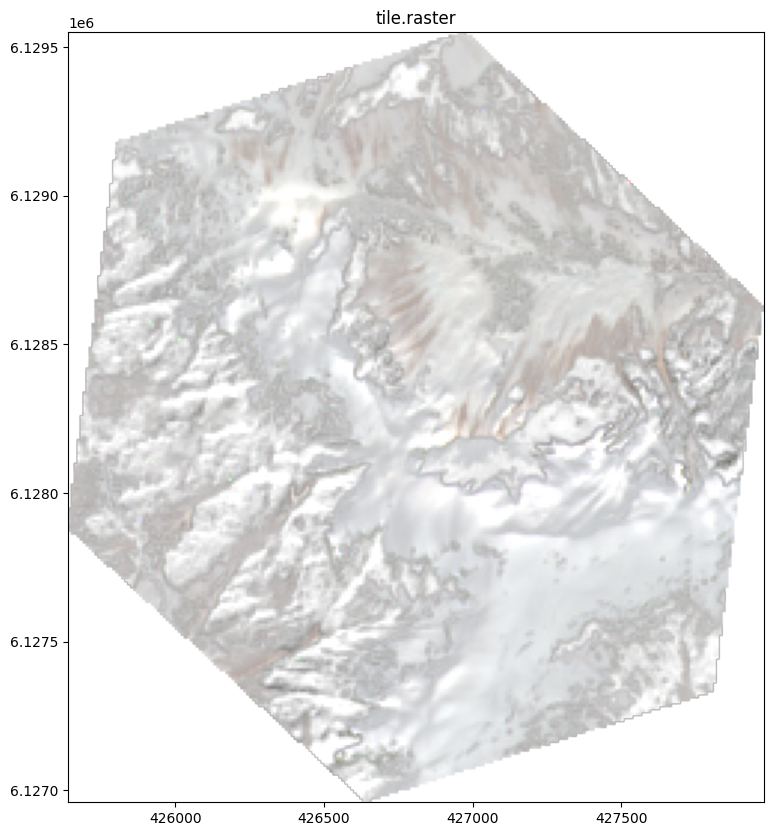

In [0]:
library.plot_raster(stacked_df.select("tile", "memsize").filter("memsize > 40000").first()["tile"]["raster"])

In [0]:
stacked_df = spark.table("band_stack")
stacked_df.limit(3).display()

cellid,date,blue_size,green_size,red_size,nir_size,tile,memsize,num_bands,blue_px,blue_w,blue_h,green_px,green_w,green_h,red_px,red_w,red_h,nir_px,nir_w,nir_h
608311683084976127,2022-06-01,45963,44478,44651,43560,"List(608311683084976127, SUkqAAgAAAATAAABAwABAAAA7QAAAAEBAwABAAAABAEAAAIBAwAEAAAA8gAAAAMBAwABAAAACAAAAAYBAwABAAAAAQAAABUBAwABAAAABAAAABwBAwABAAAAAQAAAD0BAwABAAAAAgAAAEIBAwABAAAA4AAAAEMBAwABAAAA4AA= (truncated), Map(format -> GTiff, path -> /vsimem/merge_bands_ae6e64d6_28e5_4007_86d9_98648f56e292.tif, size -> -1, compression -> DEFLATE, last_error -> , all_parents -> /vsimem/merge_bands_vrt_ae6e64d6_28e5_4007_86d9_98648f56e292.vrt;/vsimem/temp_raster_fb9819bd_02e8_4f2a_add0_5b084c9d7186.tif;/vsimem/temp_raster_f3d511f4_aa34_4955_8c91_12ab82e3d1f5.tif;/vsimem/temp_raster_78820dc0_e304_442c_99d0_e75ad5c6c590.tif;/vsimem/temp_raster_5fef800b_d0c6_4b62_b73a_503edd3f9ae1.tif, isZipped -> false, driver -> GTiff, sourcePath -> /vsimem/merge_bands_vrt_ae6e64d6_28e5_4007_86d9_98648f56e292.vrt, last_command -> gdal_translate -r bilinear -of GTiff -co TILED=YES -co BLOCKXSIZE=224 -co BLOCKYSIZE=224 -co BIGTIFF=IF_SAFER -co COMPRESS=DEFLATE -co PREDICTOR=2 -co ZLEVEL=6, isSubset -> false))",169198,4,List(44213),237,260,List(44213),237,260,List(44213),237,260,List(44213),237,260
608311601044389887,2022-06-01,63639,63071,62617,61992,"List(608311601044389887, SUkqAAgAAAATAAABAwABAAAA6AAAAAEBAwABAAAA/wAAAAIBAwAEAAAA8gAAAAMBAwABAAAACAAAAAYBAwABAAAAAQAAABUBAwABAAAABAAAABwBAwABAAAAAQAAAD0BAwABAAAAAgAAAEIBAwABAAAA4AAAAEMBAwABAAAA4AA= (truncated), Map(format -> GTiff, path -> /vsimem/merge_bands_e89fac8e_a514_443d_9b59_7b5d85083ebe.tif, size -> -1, compression -> DEFLATE, last_error -> , all_parents -> /vsimem/merge_bands_vrt_e89fac8e_a514_443d_9b59_7b5d85083ebe.vrt;/vsimem/temp_raster_a539c034_dde0_487f_809d_d869d7977232.tif;/vsimem/temp_raster_c803201c_87c9_419c_ba5c_4d1e5103a92b.tif;/vsimem/temp_raster_82bd27f1_77d7_40f0_a040_fedd9c1641e8.tif;/vsimem/temp_raster_63a59c15_2567_42fe_91ee_813f1b004689.tif, isZipped -> false, driver -> GTiff, sourcePath -> /vsimem/merge_bands_vrt_e89fac8e_a514_443d_9b59_7b5d85083ebe.vrt, last_command -> gdal_translate -r bilinear -of GTiff -co TILED=YES -co BLOCKXSIZE=224 -co BLOCKYSIZE=224 -co BIGTIFF=IF_SAFER -co COMPRESS=DEFLATE -co PREDICTOR=2 -co ZLEVEL=6, isSubset -> false))",240518,4,List(42715),232,255,List(42715),232,255,List(42715),232,255,List(42715),232,255
608311583461867519,2022-06-01,60875,64091,60919,67302,"List(608311583461867519, SUkqAAgAAAATAAABAwABAAAA6gAAAAEBAwABAAAA/wAAAAIBAwAEAAAA8gAAAAMBAwABAAAACAAAAAYBAwABAAAAAQAAABUBAwABAAAABAAAABwBAwABAAAAAQAAAD0BAwABAAAAAgAAAEIBAwABAAAA4AAAAEMBAwABAAAA4AA= (truncated), Map(format -> GTiff, path -> /vsimem/merge_bands_8f208341_8365_4caa_b1c1_79cf0880f595.tif, size -> -1, compression -> DEFLATE, last_error -> , all_parents -> /vsimem/merge_bands_vrt_8f208341_8365_4caa_b1c1_79cf0880f595.vrt;/vsimem/temp_raster_42241c21_1b56_4fbd_8939_8b3b67c6475d.tif;/vsimem/temp_raster_3e0b34c6_fde6_4cd6_97cd_81b4ef64622d.tif;/vsimem/temp_raster_5e282ade_6ea1_4ee7_97cd_16c36b4b5818.tif;/vsimem/temp_raster_fba45bc0_3805_4871_bd4a_4d7f99c5a3ab.tif, isZipped -> false, driver -> GTiff, sourcePath -> /vsimem/merge_bands_vrt_8f208341_8365_4caa_b1c1_79cf0880f595.vrt, last_command -> gdal_translate -r bilinear -of GTiff -co TILED=YES -co BLOCKXSIZE=224 -co BLOCKYSIZE=224 -co BIGTIFF=IF_SAFER -co COMPRESS=DEFLATE -co PREDICTOR=2 -co ZLEVEL=6, isSubset -> false))",252402,4,List(43164),234,255,List(43165),234,255,List(43164),234,255,List(43165),234,255


_We can also write the stacked rasters out to TIF to use in various other operations._

In [0]:
STACKED_DIR = f"{EO_DIR}/out/stacked-tif"
dbutils.fs.mkdirs(STACKED_DIR)

True

In [0]:
num_stacked_files = len(dbutils.fs.ls(STACKED_DIR))
num_stacked_files

0

`rst_tryopen` validates that each tile can actually be decoded before writing — skipping corrupt or truncated files. `rst_boundingbox` returns the tile's spatial extent as WKB, and `rst_srid` returns its coordinate reference system identifier. See [RasterX Functions](https://databrickslabs.github.io/geobrix/docs/api/raster-functions).

In [0]:
if FORCE_REBUILD or num_stacked_files == 0:
  if FORCE_REBUILD:
    dbutils.fs.rm(STACKED_DIR, True); dbutils.fs.mkdirs(STACKED_DIR)
  (
    stacked_df
      .filter("num_bands == 4")         # <- skip missing bands   
      .filter("red_px[0] > 100")        # <- skip degenerate post-clip tiles (10×10 = 100) 
      .filter("red_px = blue_px AND red_px = green_px AND red_px = nir_px") # <- skip non-matching bands
      .filter(rx.rst_tryopen("tile"))   # <- skip invalid tiles
      .withColumn("source", F.concat_ws("_", "cellid", "date"))  # deterministic filename
      .selectExpr("source", "tile")  # <- exact (source, tile) schema for gtiff_gbx
      .write
        .format("gtiff_gbx")
        .option("nameCol", "source")
        .mode("append")       # include "append" in the write 
        .option("ext", "tif") # 'tif' (default)
      .save(STACKED_DIR) 
  )
else:
  print("...skipping stacking (already have files, do you need to clean up?)")

In [0]:
len(dbutils.fs.ls(STACKED_DIR))

10383

## Clipping

> Here is a simple example of clipping each raster to an envelope around the centroid. More sophisticated examples might include clipping to geospatial features or providing a polygon as a spatial filter. 

For clipping, we build a cutline geometry from `st_envelope` (bounding box) + `st_buffer` (padding), convert to EWKB with `st_asewkb` (which carries the SRID), and pass it to `rst_clip`. The SRID embedded in the EWKB cutline tells `rst_clip` which CRS the cutline is in, so it can reproject automatically to the raster's CRS if needed. Note: `st_envelope`, `st_buffer`, `st_centroid`, `st_geomfromwkb`, and `st_asewkb` are Databricks built-in spatial functions (not GeoBrix). See [RasterX Functions](https://databrickslabs.github.io/geobrix/docs/api/raster-functions) and [xView Gotchas](https://databrickslabs.github.io/geobrix/docs/notebooks/xview#gotchas).

In [0]:
df_clip = (
  spark.read.format("binaryFile")
  .load(STACKED_DIR)
  .withColumn("tile", rx.rst_fromcontent("content", F.lit("GTiff")))
  .filter(rx.rst_isempty("tile") == False)
  .drop("content")
  .withColumn("memsize", rx.rst_memsize("tile"))
  .withColumn("num_bands", rx.rst_numbands("tile"))
  .withColumn("metadata", rx.rst_metadata("tile"))
  .withColumn("summary", rx.rst_summary("tile"))
  .withColumn("srid", rx.rst_srid("tile"))
  .withColumn("bbox", rx.rst_boundingbox("tile"))
  .withColumn("geom", DBF.st_geomfromwkb("bbox", "srid"))           # <- DBF (built-in)
  .withColumn("centroid", DBF.st_centroid("geom"))                  # ^ 
  .withColumn("buffer", DBF.st_buffer("centroid", F.lit(1000)))      # ^ 
  .withColumn("clip_wkb", DBF.st_asewkb(DBF.st_envelope("buffer"))) # ^ 
  .withColumn("clip_tile", rx.rst_clip("tile", "clip_wkb", True))
)

df_clip.limit(10).display()

path modificationTime length tile memsize num_bands metadata summary srid bbox geom centroid buffer clip_wkb clip_tile dbfs:/Volumes/geospatial_docs/eo_series_fresh/data/alaska/out/stacked-tif/943116375_40_36427.tif 2026-05-20T19:45:27Z 308087 List(0, SUkqANSsBAATAAABAwABAAAA6gAAAAEBAwABAAAABgEAAAIBAwAEAAAA8gAAAAMBAwABAAAACAAAAAYBAwABAAAAAQAAABUBAwABAAAABAAAABwBAwABAAAAAQAAAD0BAwABAAAAAgAAAEIBAwABAAAA4AAAAEMBAwABAAAA4AA= (truncated), Map(driver -> GTiff, extension -> tif, size -> 308087)) 308087 4 Map(RASTERX_CELL -> 608315094631186431, RASTERX_size -> 306387, PREDICTOR -> 2, RASTERX_driver -> GTiff, INTERLEAVE -> PIXEL, RASTERX_compression -> DEFLATE, AREA_OR_POINT -> Area, DERIVED_SUBDATASET_1_NAME -> DERIVED_SUBDATASET:LOGAMPLITUDE:/vsimem/temp_raster_4d515c8e_a0e4_4182_933f_50316ec2affd.tif, RASTERX_last_command -> gdal_translate -of GTiff -co TILED=YES -co BLOCKXSIZE=224 -co BLOCKYSIZE=224 -co BIGTIFF=IF_SAFER -co COMPRESS=DEFLATE -co PREDICTOR=2 -co ZLEVEL=6, COMPRESSION -> DEFLATE, RASTERX_all_parents -> /vsimem/temp_raster_83c43c33_77a4_4309_9f80_dd96e3ba3c9a.tif;/vsimem/merge_bands_vrt_070db758_bdc0_48b4_8b15_276ea519f5d7.vrt;/vsimem/temp_raster_dcfb436b_3291_4b31_a23d_457bd91cd265.tif;/vsimem/temp_raster_200bc232_b81b_4adf_8a97_754a216c819f.tif;/vsimem/temp_raster_989e0d1c_9cf8_4676_b2da_0c18c577b0db.tif;/vsimem/temp_raster_ec2082cb_a31c_4cf8_bd7b_1d047e99429c.tif, RASTERX_path -> /tmp/gdal_local_files/15f9adf7/6ce9cc63_ae2e_415b_ba26_6ead3346f9a6/943116375_40_36427.tif, RASTERX_sourcePath -> /vsimem/temp_raster_83c43c33_77a4_4309_9f80_dd96e3ba3c9a.tif, RASTERX_format -> GTiff, DERIVED_SUBDATASET_1_DESC -> log10 of amplitude of input bands from /vsimem/temp_raster_4d515c8e_a0e4_4182_933f_50316ec2affd.tif, RASTERX_isZipped -> false, RASTERX_isSubset -> false) {
 "description":"/vsimem/temp_raster_ec19c149_a88e_4905_b07d_2131c5e003b4.tif",
 "driverShortName":"GTiff",
 "driverLongName":"GeoTIFF",
 "files":[
 "/vsimem/temp_raster_ec19c149_a88e_4905_b07d_2131c5e003b4.tif"
 ],
 "size":[
 234,
 262
 ],
 "coordinateSystem":{
 "wkt":"PROJCRS[\"WGS 84 / UTM zone 9N\",\n BASEGEOGCRS[\"WGS 84\",\n DATUM[\"World Geodetic System 1984\",\n ELLIPSOID[\"WGS 84\",6378137,298.257223563,\n LENGTHUNIT[\"metre\",1]]],\n PRIMEM[\"Greenwich\",0,\n ANGLEUNIT[\"degree\",0.0174532925199433]],\n ID[\"EPSG\",4326]],\n CONVERSION[\"UTM zone 9N\",\n METHOD[\"Transverse Mercator\",\n ID[\"EPSG\",9807]],\n PARAMETER[\"Latitude of natural origin\",0,\n ANGLEUNIT[\"degree\",0.0174532925199433],\n ID[\"EPSG\",8801]],\n PARAMETER[\"Longitude of natural origin\",-129,\n ANGLEUNIT[\"degree\",0.0174532925199433],\n ID[\"EPSG\",8802]],\n PARAMETER[\"Scale factor at natural origin\",0.9996,\n SCALEUNIT[\"unity\",1],\n ID[\"EPSG\",8805]],\n PARAMETER[\"False easting\",500000,\n LENGTHUNIT[\"metre\",1],\n ID[\"EPSG\",8806]],\n PARAMETER[\"False northing\",0,\n LENGTHUNIT[\"metre\",1],\n ID[\"EPSG\",8807]]],\n CS[Cartesian,2],\n AXIS[\"(E)\",east,\n ORDER[1],\n LENGTHUNIT[\"metre\",1]],\n AXIS[\"(N)\",north,\n ORDER[2],\n LENGTHUNIT[\"metre\",1]],\n USAGE[\n SCOPE[\"Navigation and medium accuracy spatial referencing.\"],\n AREA[\"Between 132°W and 126°W, northern hemisphere between equator and 84°N, onshore and offshore. Canada - British Columbia (BC); NorthW Territories (NWT); Yukon. United States (USA) - Alaska (AK).\"],\n BBOX[0,-132,84,-126]],\n ID[\"EPSG\",32609]]",
 "dataAxisToSRSAxisMapping":[
 1,
 2
 ]
 },
 "geoTransform":[
 401670.0,
 10.0,
 0.0,
 6266120.0,
 0.0,
 -10.0
 ],
 "metadata":{
 "":{
 "RASTERX_all_parents":"/vsimem/temp_raster_83c43c33_77a4_4309_9f80_dd96e3ba3c9a.tif;/vsimem/merge_bands_vrt_070db758_bdc0_48b4_8b15_276ea519f5d7.vrt;/vsimem/temp_raster_dcfb436b_3291_4b31_a23d_457bd91cd265.tif;/vsimem/temp_raster_200bc232_b81b_4adf_8a97_754a216c819f.tif;/vsimem/temp_raster_989e0d1c_9cf8_4676_b2da_0c18c577b0db.tif;/vsimem/temp_raster_ec2082cb_a31c_4cf8_bd7b_1d047e99429c.tif",
 "RASTERX_CELL":"608315094631186431",
 "RASTERX_compression":"DEFLATE"

In [0]:
to_plot = df_clip.select("clip_tile").limit(10).collect()

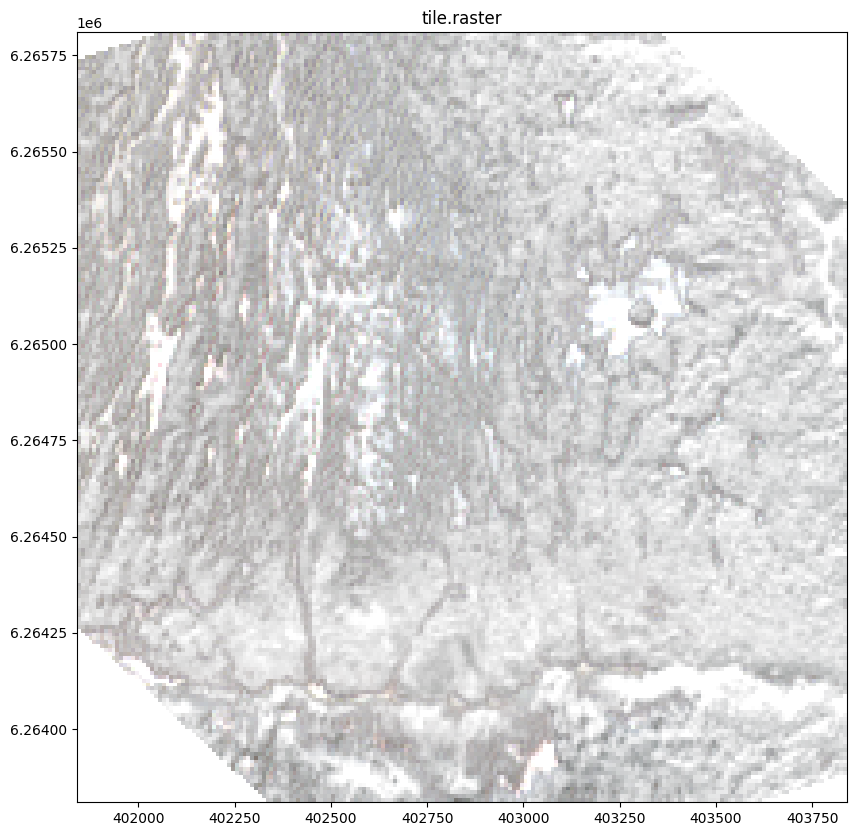

In [0]:
library.plot_raster(to_plot[0]["clip_tile"]["raster"], fig_w=10, fig_h=10) # <- you may have to change the index, e.g. [5]